In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# --- TASK 1: SELECT MODELING TECHNIQUE ---

# For Market Basket Analysis, we select the Apriori Algorithm.
# This is a classic algorithm for association rule learning over transactional databases.

modeling_technique = {
    "algorithm": "Apriori Algorithm",
    "library": "mlxtend",
    "reasoning": [
        "The data consists of categorical transactions (items bought by members).",
        "Apriori is highly efficient for identifying frequent itemsets in retail data.",
        "It allows us to calculate 'Lift', which proves if a relationship is statistically significant."
    ],
    "assumptions": [
        "A 'transaction' is defined as all items bought by the same Member on the same Date.",
        "Items bought together in one transaction are related."
    ]
}

print(f"Technique Selected: {modeling_technique['algorithm']}")
print(f"Primary Library: {modeling_technique['library']}")

Technique Selected: Apriori Algorithm
Primary Library: mlxtend


In [3]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Load the prepared data from Phase 3
df = pd.read_csv('../data/processed/prepared_groceries.csv')

# 2. Group items into transactions (one list of items per member per day)
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).tolist()

# 3. One-Hot Encode the transactions
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Transaction Matrix Created: {basket_df.shape[0]} transactions and {basket_df.shape[1]} unique items.")
basket_df.head()

Transaction Matrix Created: 14963 transactions and 167 unique items.


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [5]:
# Generate frequent itemsets
frequent_itemsets = apriori(basket_df, min_support=0.001, use_colnames=True)

# Generate the Association Rules
# We use 'lift' as our primary metric to find strong associations
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Sort by Lift to see the strongest relationships
rules = rules.sort_values('lift', ascending=False)

print(f"Found {len(rules)} association rules.")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Found 240 association rules.


,antecedents,consequents,support,confidence,lift
238,(sausage),"(whole milk, yogurt)",0.001470,0.024363,2.182917
235,"(whole milk, yogurt)",(sausage),0.001470,0.131737,2.182917
234,"(whole milk, sausage)",(yogurt),0.001470,0.164179,1.911760
239,(yogurt),"(whole milk, sausage)",0.001470,0.017121,1.911760
86,(citrus fruit),(specialty chocolate),0.001403,0.026415,1.653762
87,(specialty chocolate),(citrus fruit),0.001403,0.087866,1.653762
236,"(sausage, yogurt)",(whole milk),0.001470,0.255814,1.619866
237,(whole milk),"(sausage, yogurt)",0.001470,0.009310,1.619866
122,(tropical fruit),(flour),0.001069,0.015779,1.617141
123,(flour),(tropical fruit),0.001069,0.109589,1.617141


In [8]:
# --- TASK 4: CELL 1 - FILTERING FOR QUALITY ---

# We only keep rules that are statistically significant.
# Requirement: Lift > 1.2 (The relationship is real, not random)
# Requirement: Confidence > 0.05 (It happens in at least 5% of transactions)

strong_rules = rules[(rules['lift'] > 1.2) & (rules['confidence'] > 0.05)]

# Sort by 'Lift' so the most important rules are at the top
strong_rules = strong_rules.sort_values('lift', ascending=False)

print(f"Validation Complete: Out of {len(rules)} total rules, {len(strong_rules)} passed the quality check.")

Validation Complete: Out of 240 total rules, 37 passed the quality check.


In [9]:
# --- TASK 4: CELL 2 - RESULTS SUMMARY TABLE ---

# We create a clean table of our 'Gold' insights to put in the final report.
top_10_insights = strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).copy()

# Make the output easier to read by converting 'frozensets' to simple text
top_10_insights['Rule'] = top_10_insights['antecedents'].apply(lambda x: ', '.join(list(x))) + \
                          " -> " + \
                          top_10_insights['consequents'].apply(lambda x: ', '.join(list(x)))

# Display the final summary
print("=== TOP 10 MARKET BASKET INSIGHTS ===")
top_10_insights[['Rule', 'support', 'confidence', 'lift']].round(4)

=== TOP 10 MARKET BASKET INSIGHTS ===


,Rule,support,confidence,lift
235,"whole milk, yogurt -> sausage",0.0015,0.1317,2.1829
234,"whole milk, sausage -> yogurt",0.0015,0.1642,1.9118
87,specialty chocolate -> citrus fruit,0.0014,0.0879,1.6538
236,"sausage, yogurt -> whole milk",0.0015,0.2558,1.6199
123,flour -> tropical fruit,0.0011,0.1096,1.6171
21,beverages -> sausage,0.0015,0.0927,1.5368
229,"whole milk, soda -> sausage",0.0011,0.0920,1.5237
169,napkins -> pastry,0.0017,0.0785,1.5185
182,processed cheese -> root vegetables,0.0011,0.1053,1.5130
148,hard cheese -> pip fruit,0.0011,0.0727,1.4826


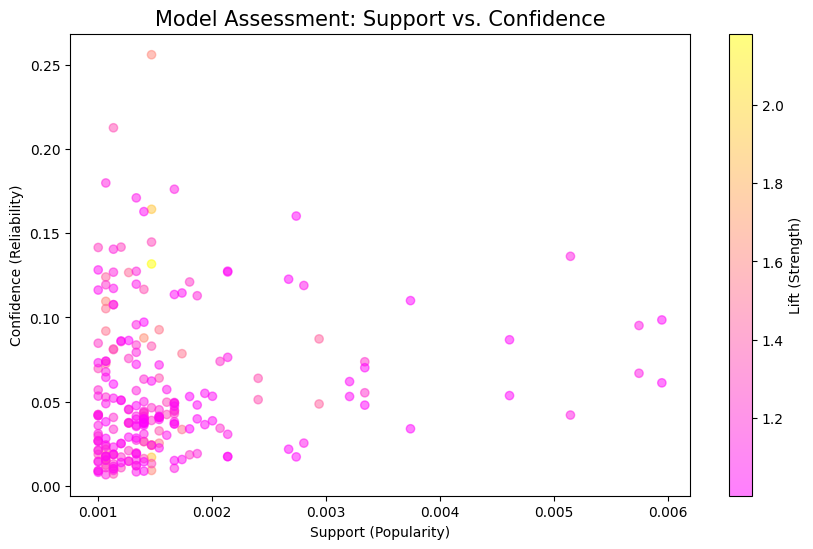

In [10]:
# --- TASK 4: CELL 3 - VISUAL ASSESSMENT ---

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], alpha=0.5, cmap='spring')
plt.colorbar(label='Lift (Strength)')
plt.title('Model Assessment: Support vs. Confidence', fontsize=15)
plt.xlabel('Support (Popularity)')
plt.ylabel('Confidence (Reliability)')
plt.show()